In [39]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv('HotelCustomersDataset.csv', sep='\t')
pd.set_option('display.max_columns', None)
# Display the first few rows of the dataset
#print(data.head())

# Display basic information about the dataset
print(data.info())

# Display summary statistics
print(data.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83590 entries, 0 to 83589
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    83590 non-null  int64  
 1   Nationality           83590 non-null  object 
 2   Age                   79811 non-null  float64
 3   DaysSinceCreation     83590 non-null  int64  
 4   NameHash              83590 non-null  object 
 5   DocIDHash             83590 non-null  object 
 6   AverageLeadTime       83590 non-null  int64  
 7   LodgingRevenue        83590 non-null  float64
 8   OtherRevenue          83590 non-null  float64
 9   BookingsCanceled      83590 non-null  int64  
 10  BookingsNoShowed      83590 non-null  int64  
 11  BookingsCheckedIn     83590 non-null  int64  
 12  PersonsNights         83590 non-null  int64  
 13  RoomNights            83590 non-null  int64  
 14  DaysSinceLastStay     83590 non-null  int64  
 15  DaysSinceFirstStay 

In [16]:
#Fill missing values
data['Age'].fillna(data['Age'].mean(), inplace=True)
#Convert the 'Age' column from float to integer
data['Age'] = data['Age'].astype(int)


In [40]:
# The demographic information of the customers

# Age distribution
print(data['Age'].describe())

# Nationality distribution
print(data['Nationality'].value_counts())


count    79811.000000
mean        45.398028
std         16.572368
min        -11.000000
25%         34.000000
50%         46.000000
75%         57.000000
max        122.000000
Name: Age, dtype: float64
Nationality
FRA    12422
PRT    11597
DEU    10232
GBR     8656
ESP     4902
       ...  
GIN        1
KNA        1
GNQ        1
JEY        1
NPL        1
Name: count, Length: 188, dtype: int64


In [27]:
# Booking patterns, such as lead time, booking channels, and special requests.

# Lead time distribution
print(data['AverageLeadTime'].describe())

# Booking channels distribution
print(data['DistributionChannel'].value_counts())
# Market Segment distribution
print(data['MarketSegment'].value_counts())

# Special requests distribution
special_requests_columns = ['SRHighFloor', 'SRLowFloor', 'SRAccessibleRoom', 'SRMediumFloor',
                      'SRBathtub', 'SRShower', 'SRCrib', 'SRKingSizeBed', 'SRTwinBed',
                      'SRNearElevator', 'SRAwayFromElevator', 'SRNoAlcoholInMiniBar', 'SRQuietRoom']
print(data[special_requests_columns].sum())


count    83590.000000
mean        66.196028
std         87.758990
min         -1.000000
25%          0.000000
50%         29.000000
75%        103.000000
max        588.000000
Name: AverageLeadTime, dtype: float64
DistributionChannel
Travel Agent/Operator      68569
Direct                     11912
Corporate                   2600
Electronic Distribution      509
Name: count, dtype: int64
MarketSegment
Other                    48039
Travel Agent/Operator    11670
Direct                   11457
Groups                    9501
Corporate                 2169
Complementary              510
Aviation                   244
Name: count, dtype: int64
SRHighFloor              3969
SRLowFloor                118
SRAccessibleRoom           21
SRMediumFloor              73
SRBathtub                 238
SRShower                  143
SRCrib                   1105
SRKingSizeBed           29481
SRTwinBed               11915
SRNearElevator             28
SRAwayFromElevator        293
SRNoAlcoholInMiniBar 

In [41]:
# Stay patterns, such as the number of room nights and person nights.

# Room nights distribution
print(data['RoomNights'].describe())

# Person nights distribution
print(data['PersonsNights'].describe())

# Days since last stay
print(data['DaysSinceLastStay'].describe())

# Days since first stay
print(data['DaysSinceFirstStay'].describe())


count    83590.000000
mean         2.358536
std          2.281746
min          0.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        185.000000
Name: RoomNights, dtype: float64
count    83590.000000
mean         4.649133
std          4.567673
min          0.000000
25%          1.000000
50%          4.000000
75%          6.000000
max        116.000000
Name: PersonsNights, dtype: float64
count    83590.000000
mean       401.067137
std        347.204955
min         -1.000000
25%         26.000000
50%        366.000000
75%        693.000000
max       1104.000000
Name: DaysSinceLastStay, dtype: float64
count    83590.000000
mean       403.349013
std        347.971089
min         -1.000000
25%         27.000000
50%        369.000000
75%        697.000000
max       1186.000000
Name: DaysSinceFirstStay, dtype: float64


In [42]:
# Revenue data to understand the financial performance
# Total revenue distribution
print(data['LodgingRevenue'].describe())

# Other revenue distribution
print(data['OtherRevenue'].describe())

data['TotalRevenue'] = data['LodgingRevenue'] + data['OtherRevenue']
# Total revenue distribution
print(data['TotalRevenue'].describe())

count    83590.000000
mean       298.802087
std        372.851892
min          0.000000
25%         59.000000
50%        234.000000
75%        402.000000
max      21781.000000
Name: LodgingRevenue, dtype: float64
count    83590.000000
mean        67.589132
std        114.327776
min          0.000000
25%          2.000000
50%         38.500000
75%         87.675000
max       7730.250000
Name: OtherRevenue, dtype: float64
count    83590.000000
mean       366.391219
std        443.800439
min          0.000000
25%         73.000000
50%        286.425000
75%        497.300000
max      23365.000000
Name: TotalRevenue, dtype: float64


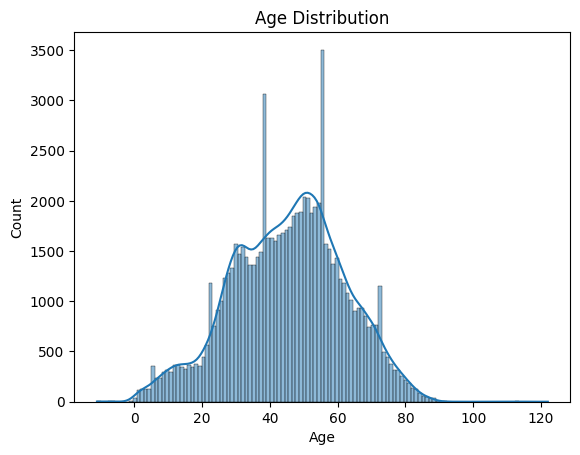

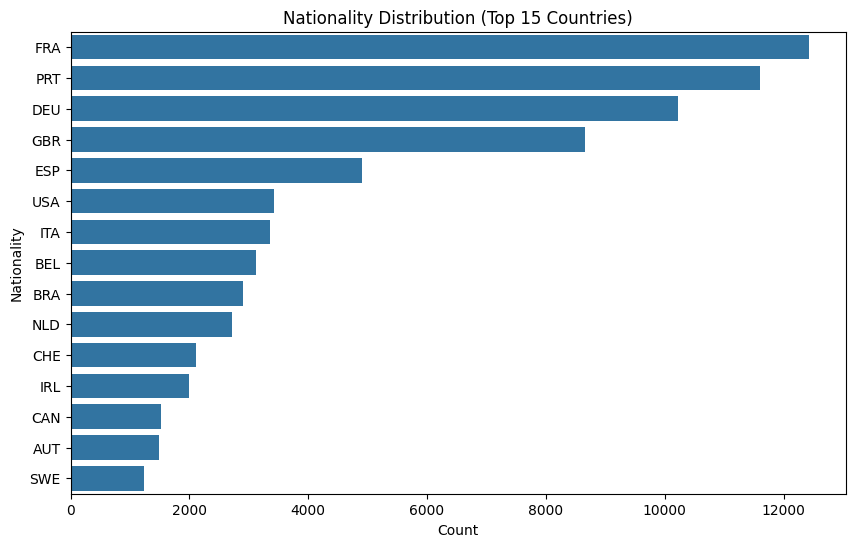

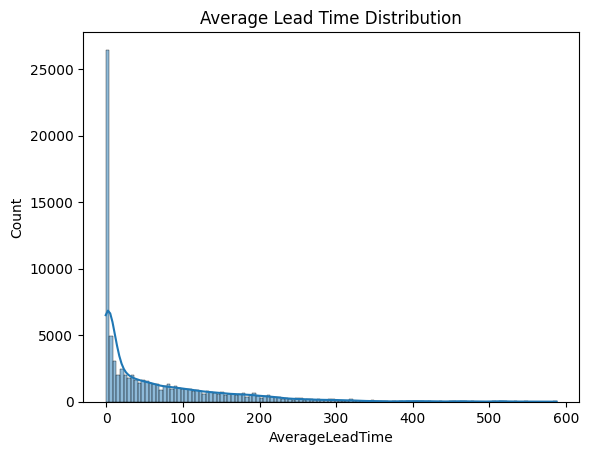

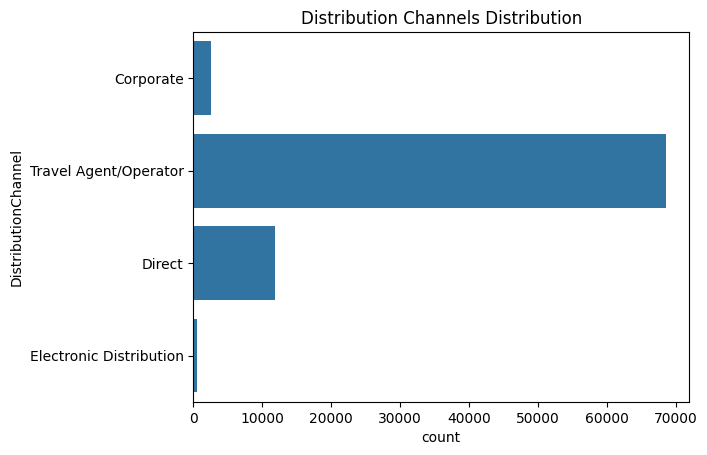

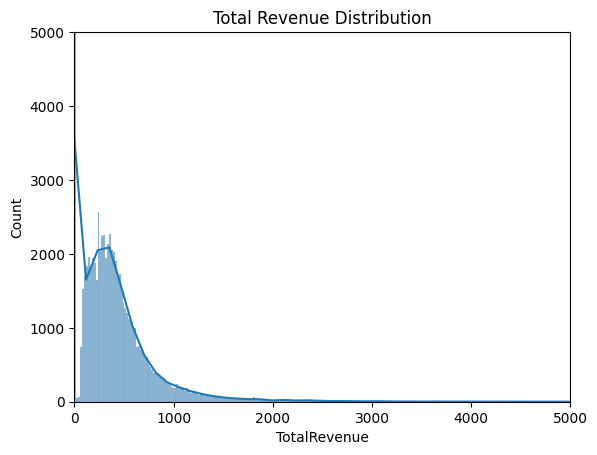

In [43]:
# Age distribution plot
sns.histplot(data['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

# Count the occurrences of each nationality
nationality_counts = data['Nationality'].value_counts()

# Select the top 15 nationalities
top_15_nationalities = nationality_counts.head(15).index

# Filter the dataset to include only the top 15 nationalities
filtered_data = data[data['Nationality'].isin(top_15_nationalities)]

# Plot the nationality distribution for the top 15 countries
plt.figure(figsize=(10, 6))
sns.countplot(y='Nationality', data=filtered_data, order=top_15_nationalities)
plt.title('Nationality Distribution (Top 15 Countries)')
plt.xlabel('Count')
plt.ylabel('Nationality')
plt.show()

# Lead time distribution plot
sns.histplot(data['AverageLeadTime'], kde=True)
plt.title('Average Lead Time Distribution')
plt.show()

# Booking channels distribution plot
sns.countplot(y='DistributionChannel', data=data)
plt.title('Distribution Channels Distribution')
plt.show()

# Total Revenue distribution plot
sns.histplot(data['TotalRevenue'], kde=True)
plt.title('Total Revenue Distribution')
plt.xlim(0, 5000)
plt.ylim(0, 5000)
plt.show()
